
테스트 파일 처리 중: test_looking_3loop_l02.csv
12/12 [==============================] - 1s 7ms/step


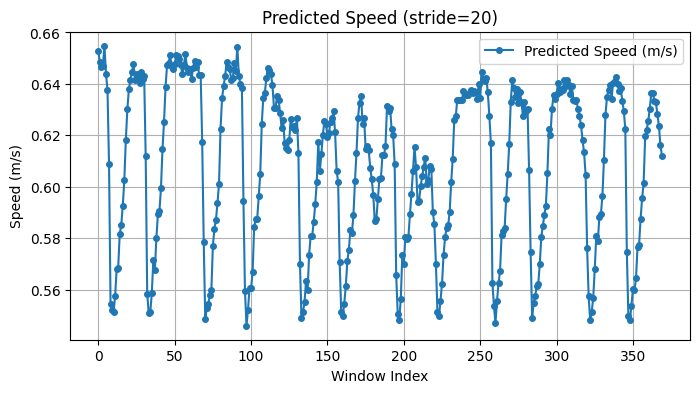

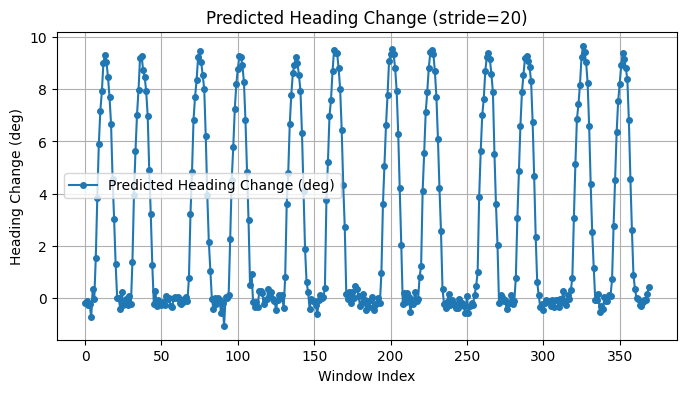

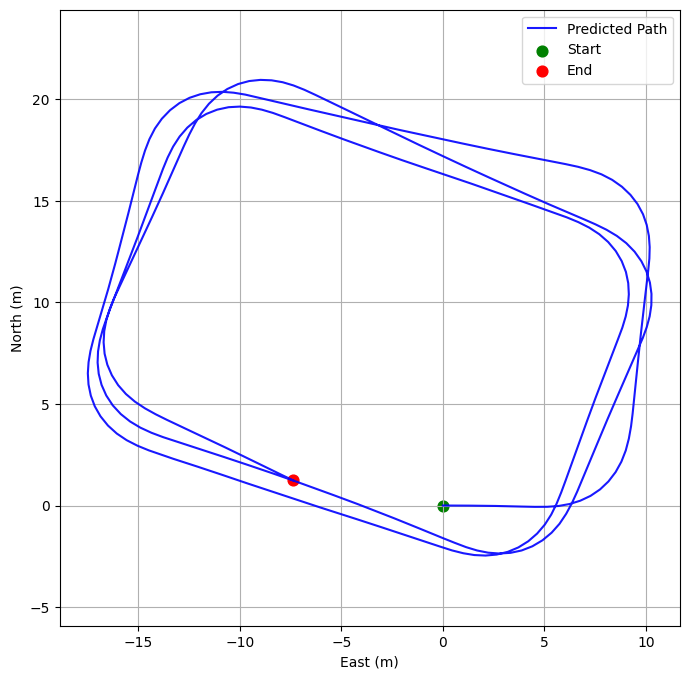

Start-End distance: 7.464 m
Heading Error (deg): -25.525 deg


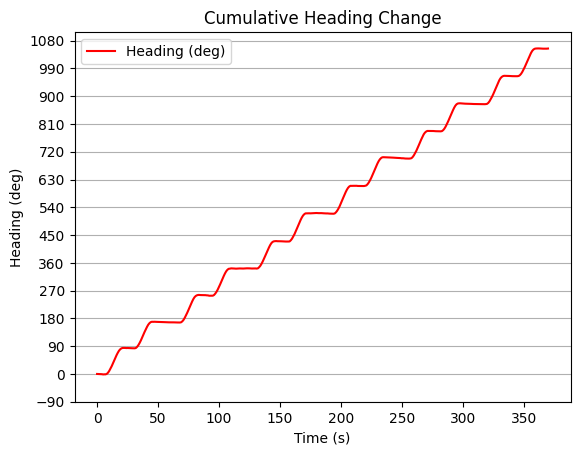


테스트 파일 처리 중: test_looking_3loop_r01.csv
12/12 [==============================] - 0s 9ms/step


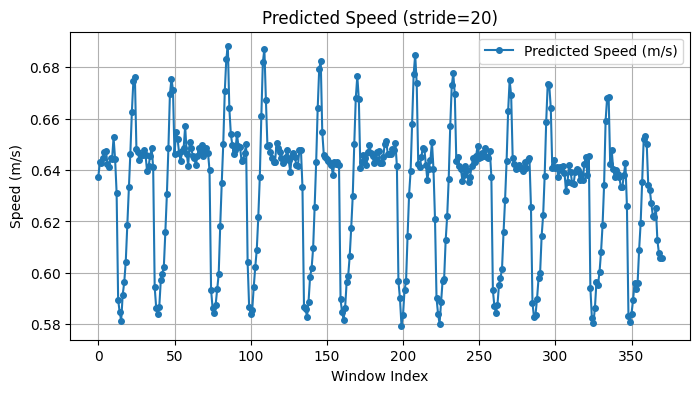

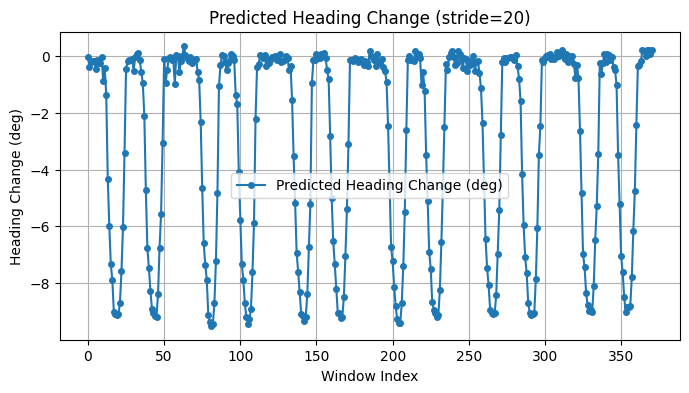

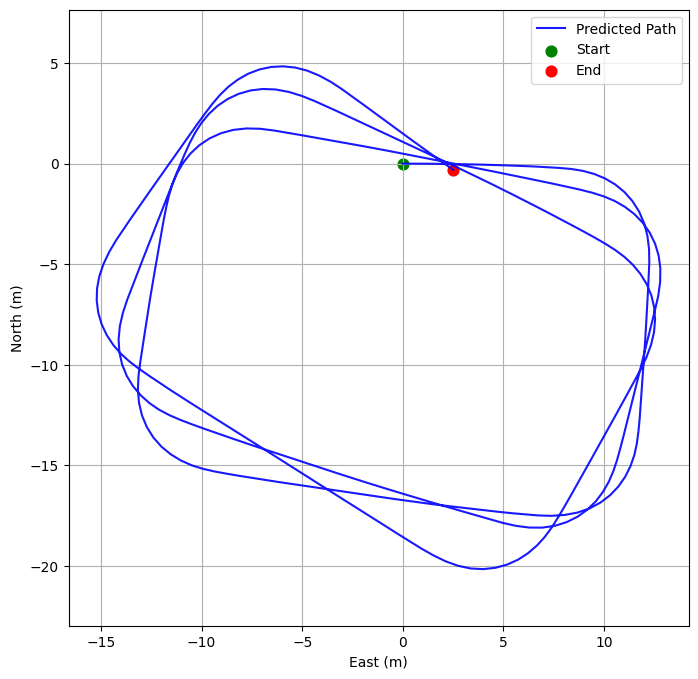

Start-End distance: 2.518 m
Heading Error (deg): 35.383 deg


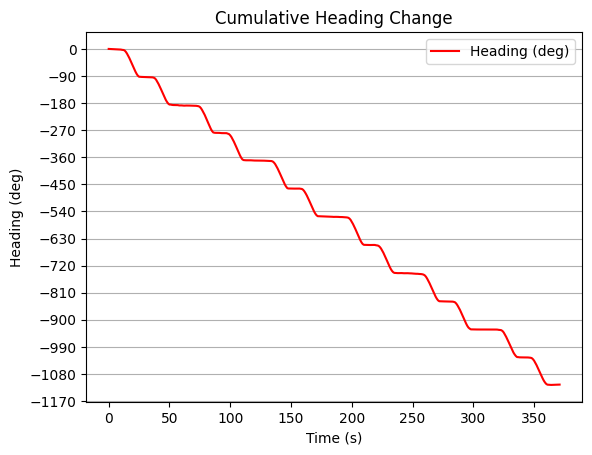


테스트 파일 처리 중: test_swing_3loop_l01.csv
12/12 [==============================] - 0s 7ms/step


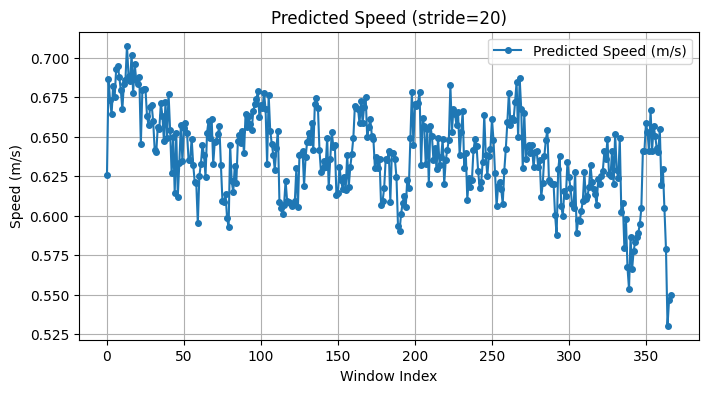

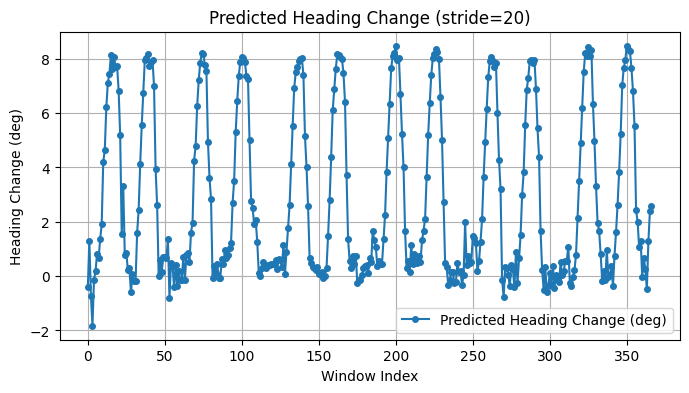

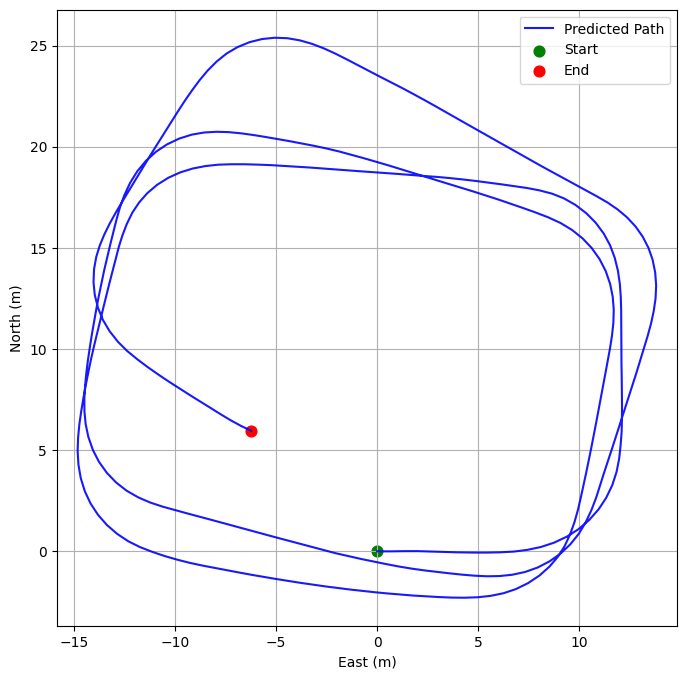

Start-End distance: 8.618 m
Heading Error (deg): -25.843 deg


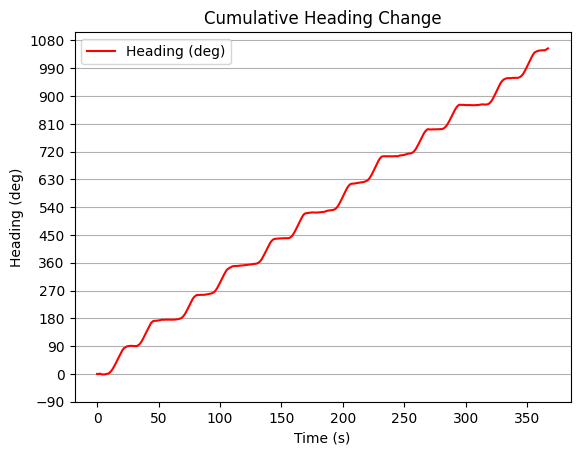


테스트 파일 처리 중: test_swing_3loop_r02.csv
12/12 [==============================] - 0s 7ms/step


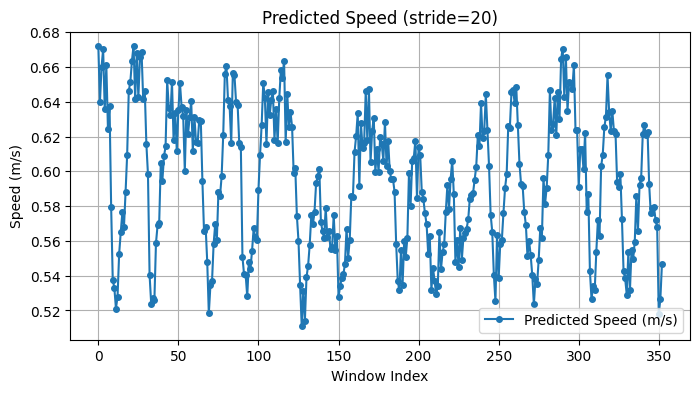

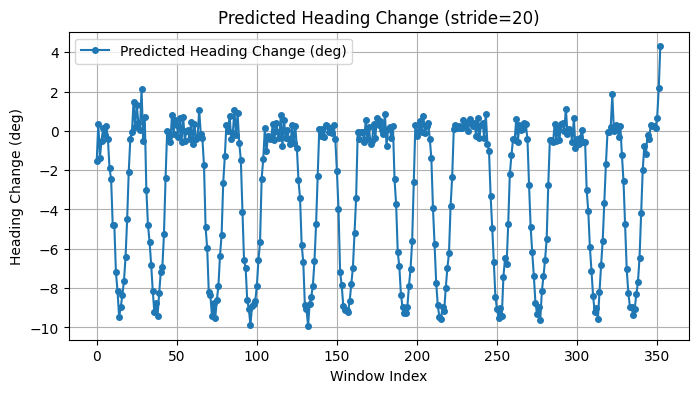

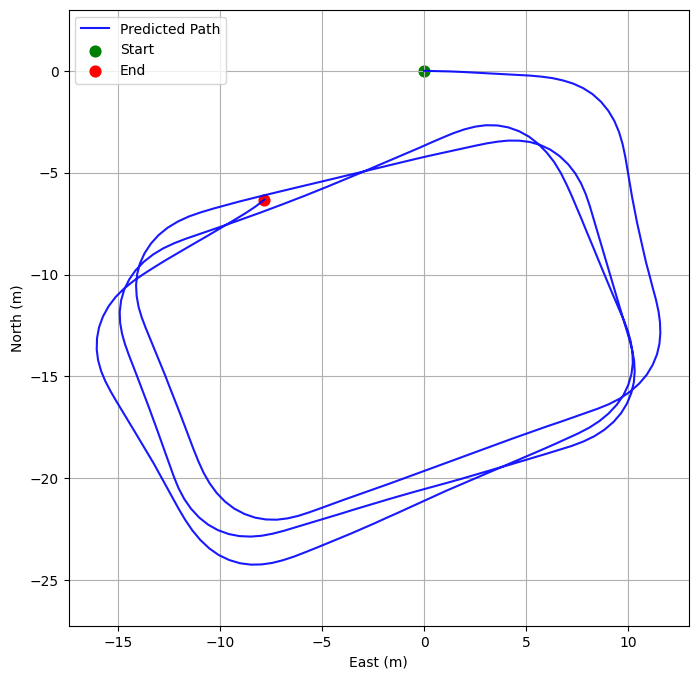

Start-End distance: 10.068 m
Heading Error (deg): -37.980 deg


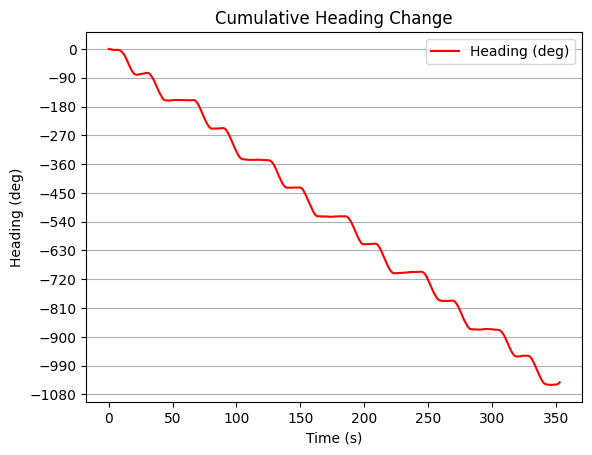


테스트 파일 처리 중: test_calling_3loop_l02.csv
12/12 [==============================] - 0s 7ms/step


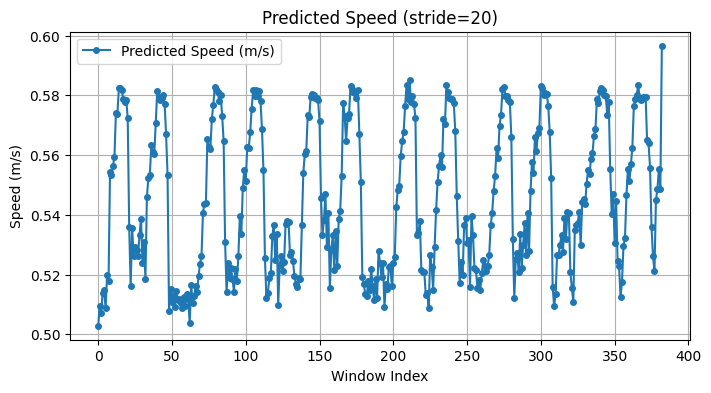

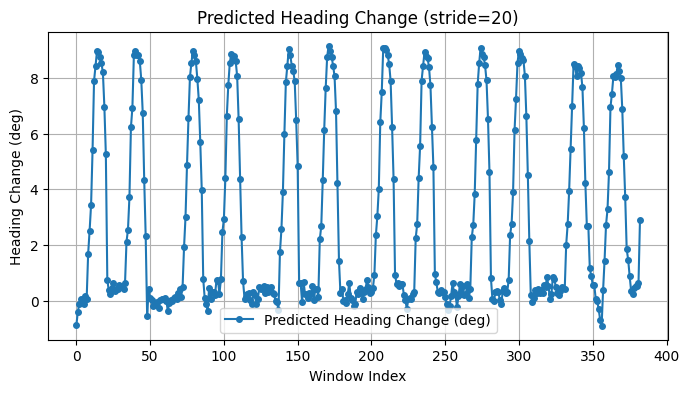

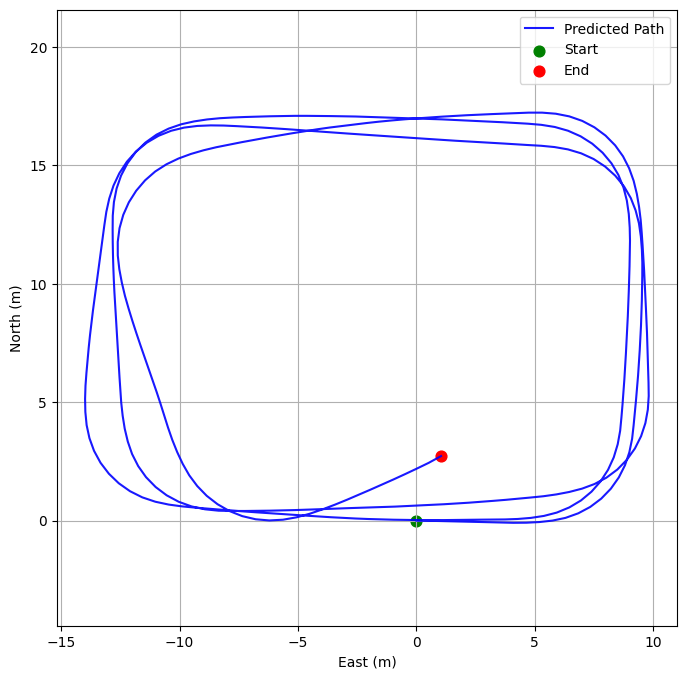

Start-End distance: 2.917 m
Heading Error (deg): 28.707 deg


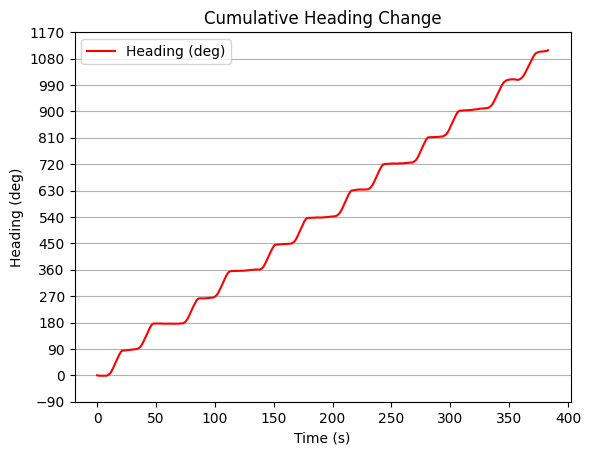


테스트 파일 처리 중: test_calling_3loop_r04.csv
12/12 [==============================] - 0s 7ms/step


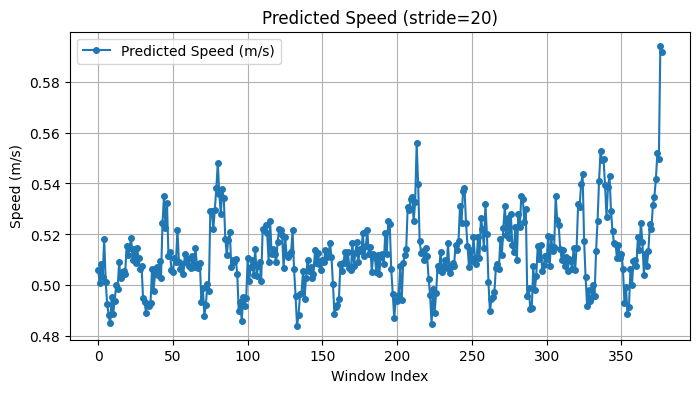

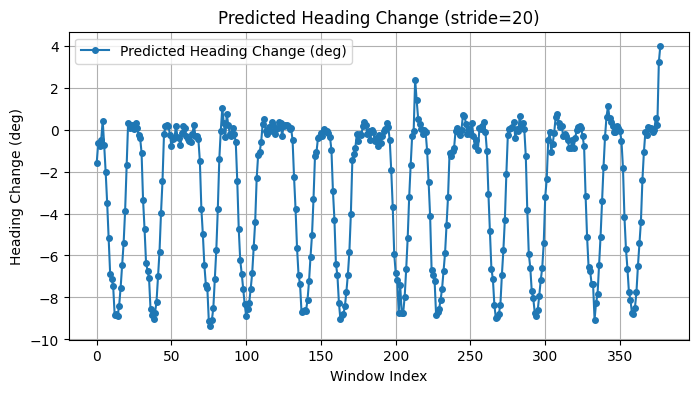

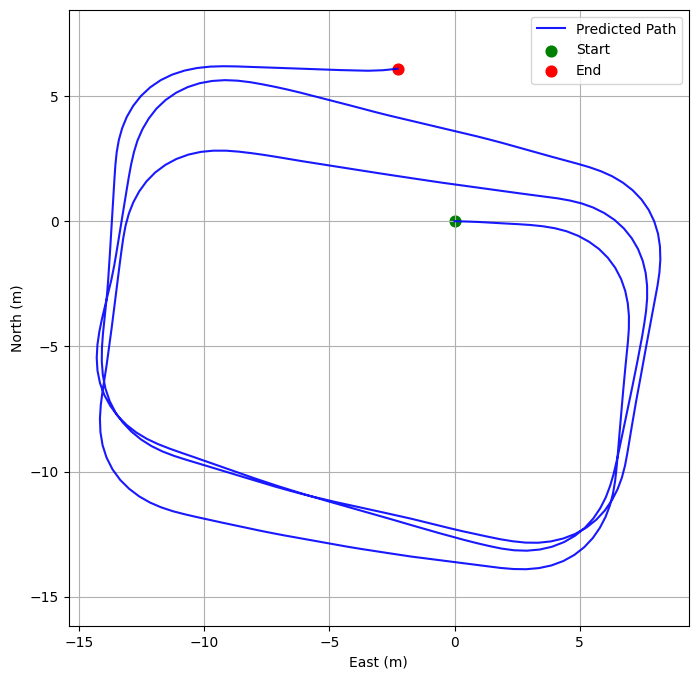

Start-End distance: 6.503 m
Heading Error (deg): -5.980 deg


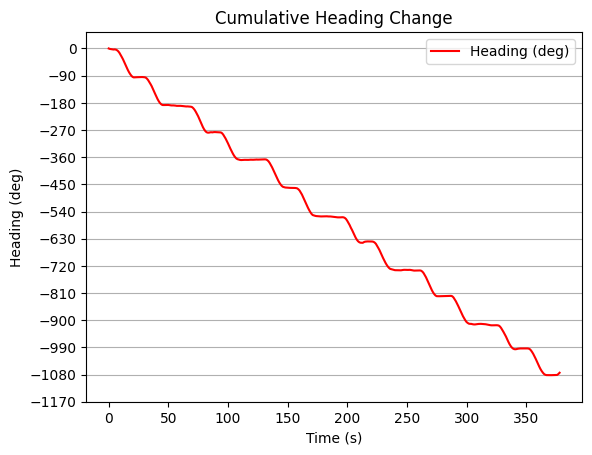


=== 전체 테스트 결과 ===
평균 위치 오차: 6.348 m
평균 헤딩 오차: -5.206 deg


In [1]:
import os
import numpy as np
from src.data_processor import DataProcessor
from src.model_trainer import ModelTrainer
from src.trajectory_predictor import TrajectoryPredictor
import matplotlib.pyplot as plt
import random
import tensorflow as tf

# 시드 값 고정
SEED = 1
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


def main():
    BASE_DIR = os.getcwd()
    window_size = 200

    # model_path = os.path.join(BASE_DIR, 'saved_models', 'model_LSTM_Attention_ws200_20250915_174720.h5') #200, batch_size: 128
    model_path = os.path.join(
        BASE_DIR, "saved_models", "ws200_20251022_164209.h5"
    )  # 200, batch_size: 256
    trainer = ModelTrainer(window_size, num_features=8)
    trainer.load_model(model_path)

    predictor = TrajectoryPredictor(
        trainer.model,
        trainer.sensor_scalers,
        trainer.y_speed_scaler,
        trainer.y_hc_scaler,
        window_size=window_size,
    )

    test_paths = [
        #Boseong Kim test data
        #os.path.join(BASE_DIR, "data", "test_data", "looking", "test_looking_3loop_l01.csv"),
        os.path.join(BASE_DIR, "data", "test_data", "looking", "test_looking_3loop_l02.csv"),
        
        os.path.join(BASE_DIR, "data", "test_data", "looking", "test_looking_3loop_r01.csv"),
        #os.path.join(BASE_DIR, "data", "test_data", "looking", "test_looking_3loop_r02.csv"),
        #os.path.join(BASE_DIR, "data", "test_data", "looking", "test_looking_3loop_r03.csv"),
        
        #os.path.join(BASE_DIR, "data", "test_data", "looking", "test_looking_5loop_l01.csv"),
        #os.path.join(BASE_DIR, "data", "test_data", "looking", "test_looking_5loop_l02.csv"),
        
        os.path.join(BASE_DIR, "data", "test_data", "swing", "test_swing_3loop_l01.csv"),
        #os.path.join(BASE_DIR, "data", "test_data", "swing", "test_swing_3loop_l02.csv"),
        
        #os.path.join(BASE_DIR, "data", "test_data", "swing", "test_swing_3loop_r01.csv"),
        os.path.join(BASE_DIR, "data", "test_data", "swing", "test_swing_3loop_r02.csv"),
        
        #os.path.join(BASE_DIR, "data", "test_data", "calling", "test_calling_3loop_l01.csv"),
        os.path.join(BASE_DIR, "data", "test_data", "calling", "test_calling_3loop_l02.csv"),
        
        #os.path.join(BASE_DIR, "data", "test_data", "calling", "test_calling_3loop_r01.csv"),
        #os.path.join(BASE_DIR, "data", "test_data", "calling", "test_calling_3loop_r02.csv"),
        #os.path.join(BASE_DIR, "data", "test_data", "calling", "test_calling_3loop_r03.csv"),
        os.path.join(BASE_DIR, "data", "test_data", "calling", "test_calling_3loop_r04.csv"),
        
    ]

    heading_errors = []
    dists = []

    # # 각 테스트 파일에 대해 예측 수행
    for test_path in test_paths:
        if os.path.exists(test_path):
            print(f"\n테스트 파일 처리 중: {os.path.basename(test_path)}")

            # 테스트 데이터 로드 및 전처리
            df_test = DataProcessor.load_and_preprocess_csv_test(test_path, skiprows=100)

            # 예측 경로 시각화
            dist, heading_error = predictor.predict_and_plot_trajectory(df_test, False)
            # predictor.predict_and_plot_trajectory(df_test, True)

            dists.append(dist)
            heading_errors.append(heading_error)

        else:
            print(f"테스트 파일을 찾을 수 없습니다: {test_path}")

    print("\n=== 전체 테스트 결과 ===")
    print(f"평균 위치 오차: {np.mean(dists):.3f} m")
    print(f"평균 헤딩 오차: {np.mean(heading_errors):.3f} deg")

if __name__ == "__main__":
    main()